## Modified Lotka-Volterra

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%reset -f
# %pip install matplotlib

In [ ]:
import jax
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt

import sys
import os

# Add the parent folder (OTF) to sys.path
project_root = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(project_root)

import otf
from otf import optim
from otf import time_integration as ti
from otf.asyncd import utils
from otf.system import System_ModelKnown

from plot import plot_species_parameters

import numpy as np

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

jndarray = jnp.ndarray

In [ ]:
def get_initial_values(N):
    # Random starting populations between 0.1 and 1.5
    u0 = jnp.array(
        jax.random.uniform(jax.random.PRNGKey(0), (N,), minval=0.1, maxval=1.5)
    )
    un0 = u0
    return u0, un0


# Monod-style parameter pack/unpack (Holling type II) with optional linear A interaction
def pack_monod_params(b0, B, K, A=None):
    if A is None:
        A = jnp.zeros_like(B)
    return jnp.concatenate([b0.ravel(), B.ravel(), K.ravel(), A.ravel()])


def unpack_monod_params(gs, N):
    expected = N + 3 * N * N
    assert gs.shape[0] == expected, (
        f"expected {expected} params but got {gs.shape[0]}"
    )
    b0 = gs[:N]
    idx = N
    B = gs[idx : idx + N * N].reshape((N, N))
    idx += N * N
    K = gs[idx : idx + N * N].reshape((N, N))
    idx += N * N
    A = gs[idx : idx + N * N].reshape((N, N))
    return b0, B, K, A


def monod_lotka_volterra(gs: jndarray, x: jndarray) -> jndarray:
    N = x.shape[0]
    b0, B, K, A = unpack_monod_params(gs, N)

    # Holling type II Monod term with exponent n=1
    # b_i(x) = b0_i + sum_j B_ij * x_j / (K_ij + x_j)
    x_tile = jnp.broadcast_to(x[None, :], (N, N))  # (N,N)
    monod_term = jnp.sum(B * x_tile / (K + x_tile), axis=1)
    b = b0 + monod_term

    dx = x * (b + A @ x)
    return dx


N = 4  # number of species


# Generate a monod-style true parameter set
def make_monod_gs(N, rng_key):
    k1, k2, k3, k4 = jax.random.split(rng_key, 4)
    b0 = jax.random.uniform(k1, (N,), minval=0.0, maxval=1.0)
    mask = jax.random.bernoulli(k2, p=0.4, shape=(N, N))
    B = jnp.where(
        mask, jax.random.uniform(k3, (N, N), minval=0.0, maxval=1.0), 0.0
    )
    K = jax.random.uniform(k4, (N, N), minval=0.01, maxval=0.1)
    A = -5.0 * jnp.eye(N) + (-1.0) * (1 - jnp.eye(N))
    return pack_monod_params(b0, B, K, A)


gs = make_monod_gs(N, jax.random.PRNGKey(1))
cs = gs + 0.5 * jnp.ones_like(gs)

# Initial populations
true0, assimilated0 = get_initial_values(N)

mu = 20
observed_slice = jnp.s_[:]
observed_mask = otf.system.utils.mask_from_slice(observed_slice, true0.shape)

system = System_ModelKnown(
    mu, gs, cs, observed_mask, monod_lotka_volterra, monod_lotka_volterra
)

solver = ti.ForwardEuler(system)
solver = ti.TwoStepAdamsBashforth(system, solver)

optimizer = optax.adam(5e-4)
optimizer = optim.OptaxWrapper(system, optimizer)

dt = 0.01
T0, Tf = 0, 10000
t_relax = 1

trues, tls_ = solver.solve_true(true0, T0, Tf, dt)
true_observed = trues[:, system.observed_mask]

cs, u_errors, tls, assimilateds = utils.run_update(
    system,
    true_observed,
    solver,
    dt,
    T0,
    Tf,
    t_relax,
    assimilated0,
    optimizer=optimizer,
    return_all=True,
)

cs = np.nan_to_num(cs, nan=0.0, posinf=1e6, neginf=-1e6)

# Plot species 0 with new per-species function
fig, axs = plot_species_parameters(
    cs=cs,
    gs=gs,
    tls=tls,
    species_index=0,
    N=N,
    u_errors=u_errors,
    include_K=True,
)
plt.show()

# Plot species N-1 with new per-species function
fig, axs = plot_species_parameters(
    cs=cs,
    gs=gs,
    tls=tls,
    species_index=N - 1,
    N=N,
    u_errors=u_errors,
    include_K=True,
)
plt.show()

NameError: name 'plot_species_parameters' is not defined

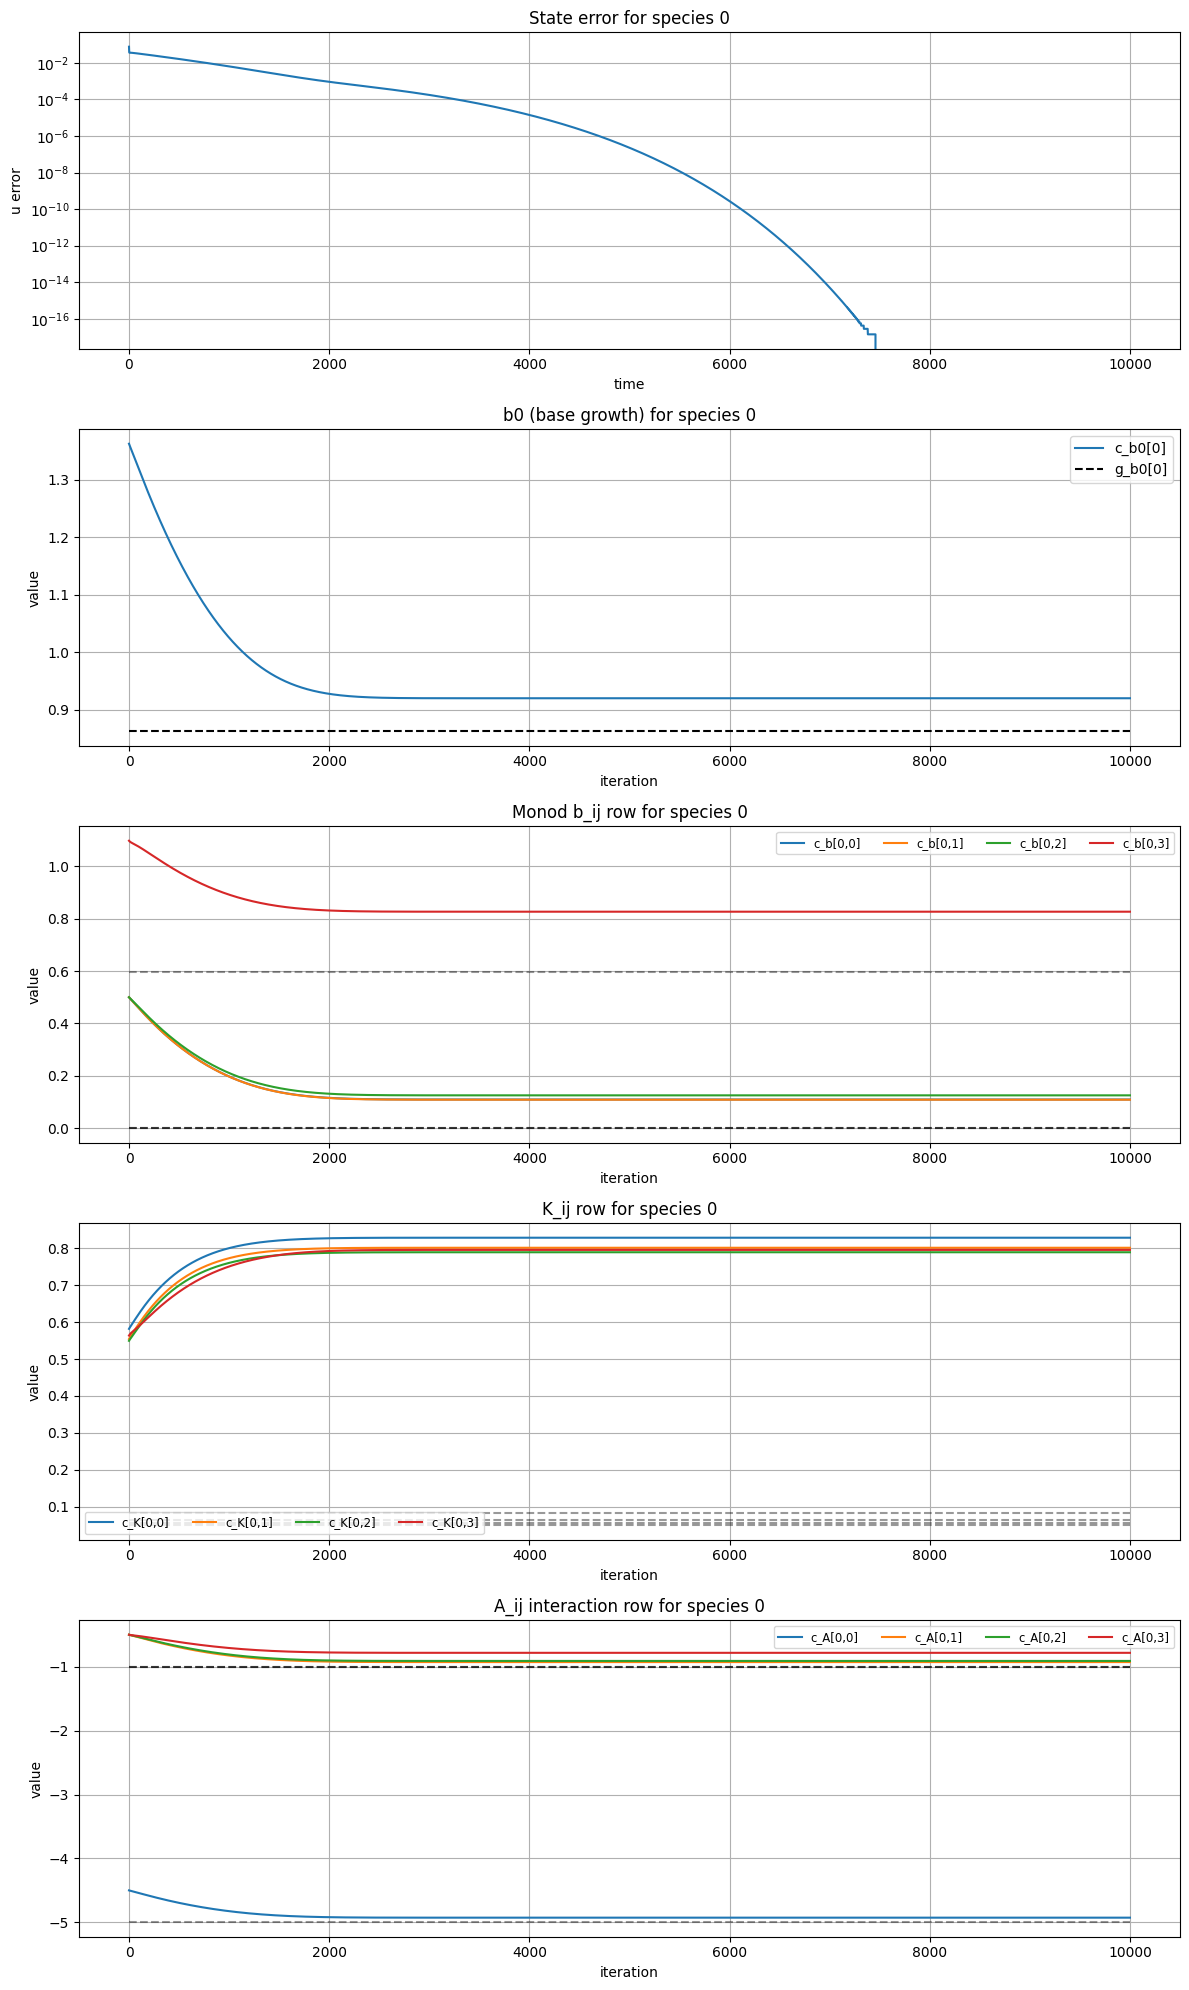

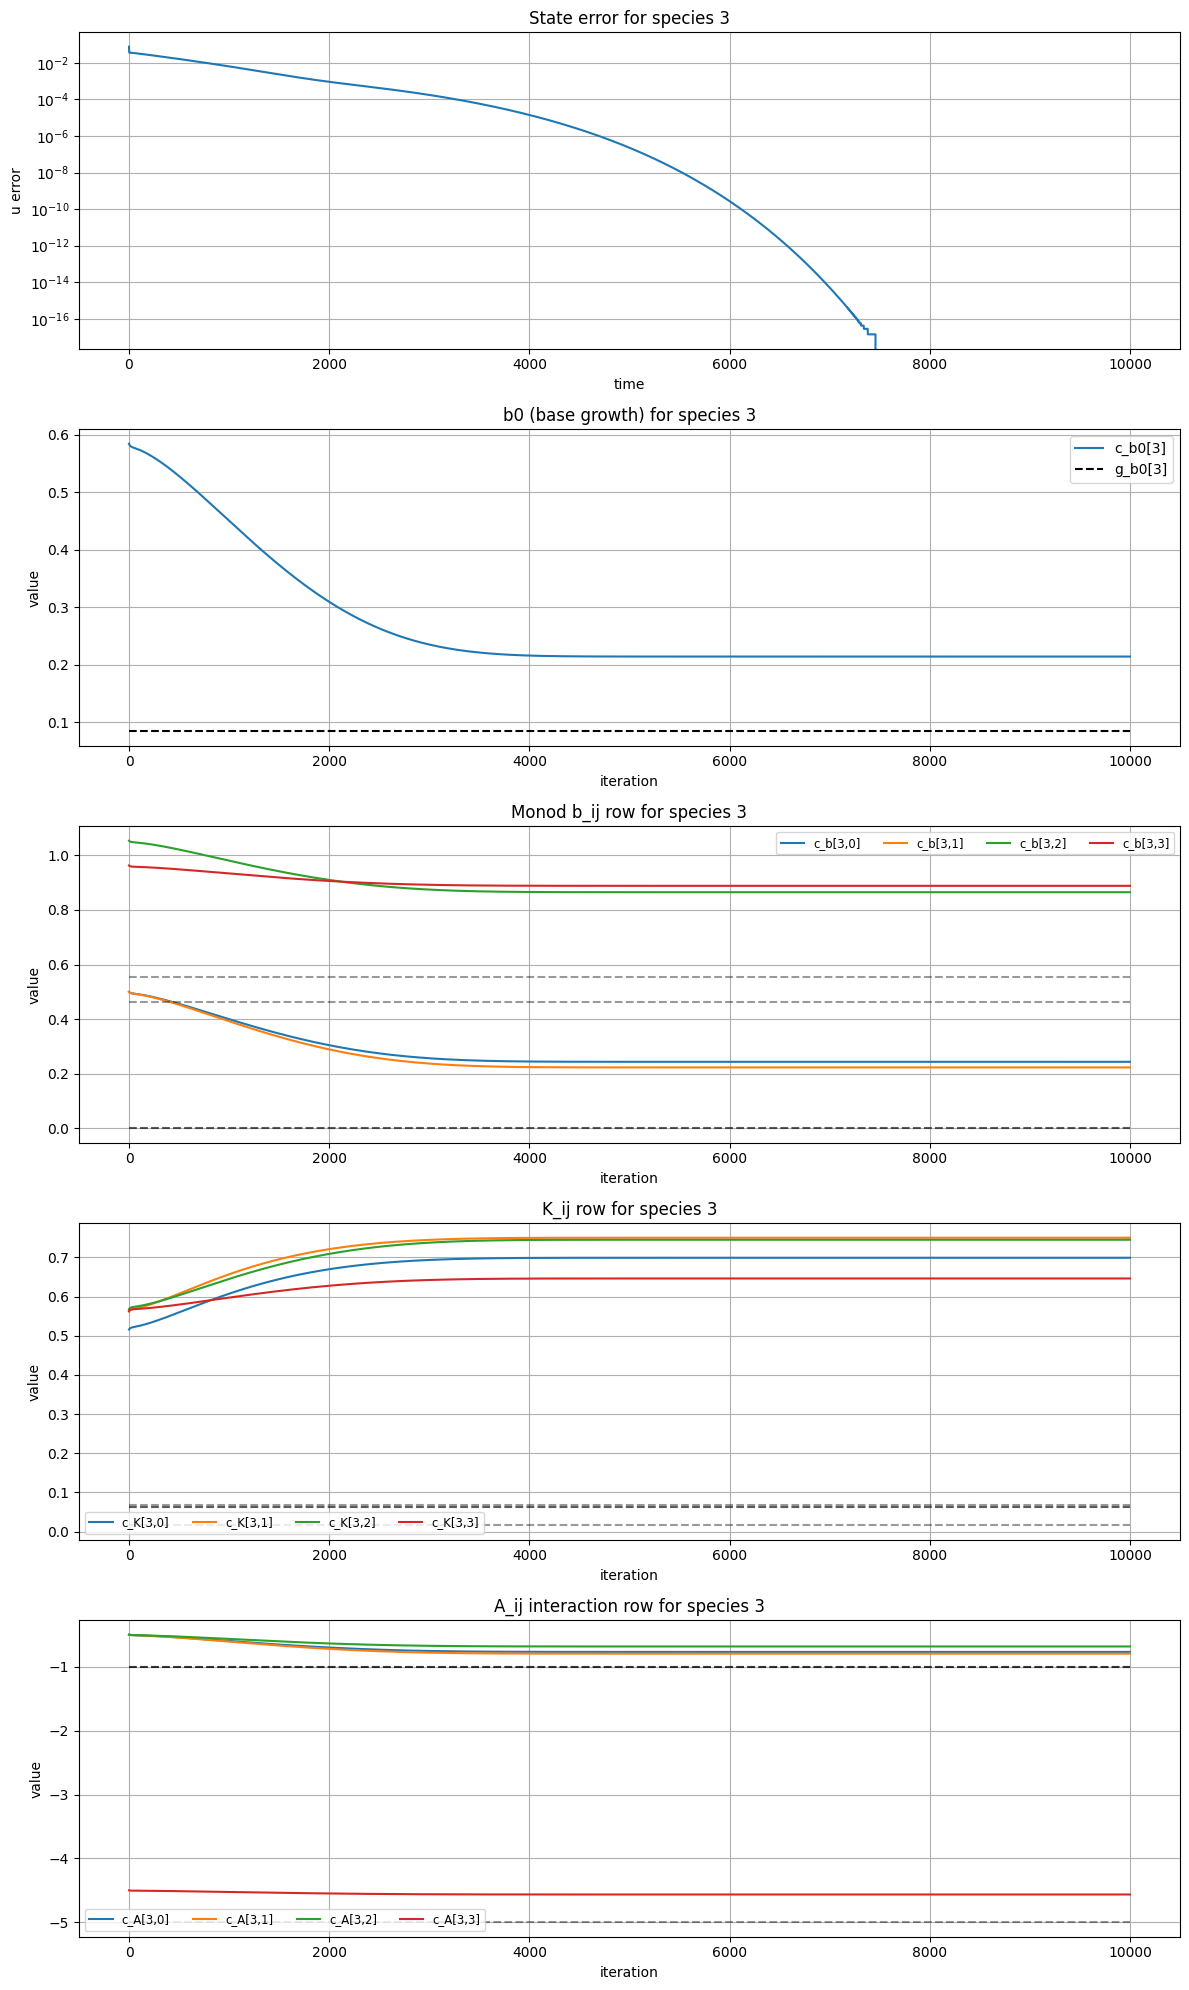

In [ ]:
fig, axs = plot_species_parameters(
    cs=cs,
    gs=gs,
    tls=tls,
    species_index=0,
    N=N,
    u_errors=u_errors,
    include_K=True,
)
plt.show()

# Plot species N-1 with new per-species function
fig, axs = plot_species_parameters(
    cs=cs,
    gs=gs,
    tls=tls,
    species_index=N - 1,
    N=N,
    u_errors=u_errors,
    include_K=True,
)
plt.show()